In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# train models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import roc_curve, auc, roc_auc_score
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Method 1: Generate synthetic classification data
print("Generating synthetic dataset...")
X, y = make_classification(
    n_samples=1000,          # Number of samples
    n_features=10,           # Number of features
    n_informative=5,         # Number of useful features
    n_redundant=2,           # Number of redundant features
    n_clusters_per_class=1,  # Number of clusters per class
    class_sep=0.8,           # Class separation (higher = easier to classify)
    random_state=42
)




Generating synthetic dataset...


In [4]:
# Convert to DataFrame for easier handling
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['target'].value_counts()}")

# Split into features and target
X = df.drop('target', axis=1)
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Dataset shape: (1000, 11)
Class distribution:
target
0    500
1    500
Name: count, dtype: int64


In [5]:
# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}


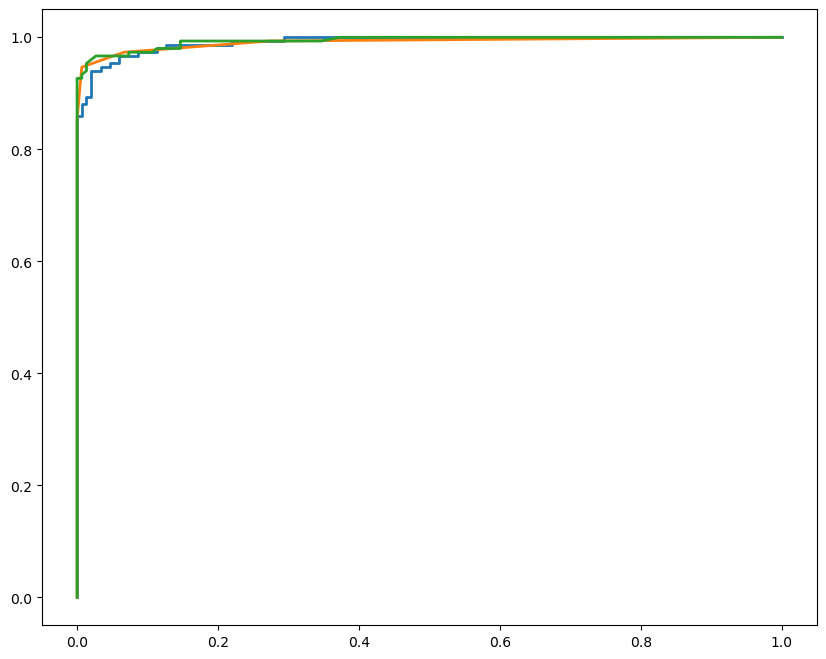

In [7]:
# Train models and get predictions
model_results = {}
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Train model
    if name == 'KNN':
        model.fit(X_train_scaled, y_train)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Store results
    model_results[name] = {
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'probabilities': y_pred_proba
    }

    # Plot ROC curve
    plt.plot(fpr, tpr, linewidth=2, 
             label=f'{name} (AUC = {roc_auc:.3f})')

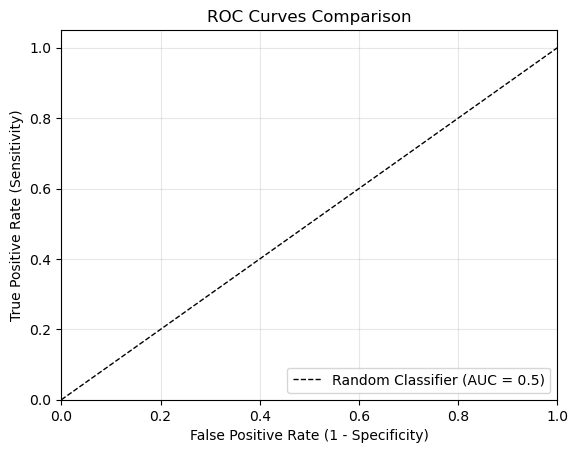

In [9]:
# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Print AUC scores
print("\nAUC Scores:")
print("-" * 30)
for name, results in model_results.items():
    print(f"{name:20}: {results['auc']:.4f}")

# Demonstrate different AUC interpretations
print("\nAUC Interpretation Guide:")
print("-" * 40)
print("AUC = 0.5  : Random classifier (no predictive ability)")
print("0.5 < AUC < 0.7 : Poor performance")
print("0.7 ≤ AUC < 0.8 : Fair performance") 
print("0.8 ≤ AUC < 0.9 : Good performance")
print("AUC ≥ 0.9  : Excellent performance")
print("AUC = 1.0  : Perfect classifier")


AUC Scores:
------------------------------
Logistic Regression : 0.9918
KNN                 : 0.9911
Random Forest       : 0.9939

AUC Interpretation Guide:
----------------------------------------
AUC = 0.5  : Random classifier (no predictive ability)
0.5 < AUC < 0.7 : Poor performance
0.7 ≤ AUC < 0.8 : Fair performance
0.8 ≤ AUC < 0.9 : Good performance
AUC ≥ 0.9  : Excellent performance
AUC = 1.0  : Perfect classifier


In [11]:
from sklearn.datasets import load_breast_cancer, load_wine, load_digits
from sklearn.datasets import fetch_openml

# Option 1: Breast Cancer Dataset (binary classification)
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
print("Breast Cancer Dataset:", X.shape, "Classes:", len(np.unique(y)))

# Option 2: Wine Dataset (can be converted to binary)
wine = load_wine()
X, y = wine.data, (wine.target == 0).astype(int)  # Class 0 vs Others
print("Wine Dataset (binary):", X.shape)

# Option 3: Digits Dataset (can be converted to binary)
digits = load_digits()
X, y = digits.data, (digits.target >= 5).astype(int)  # 0-4 vs 5-9
print("Digits Dataset (binary):", X.shape)

# Option 4: Titanic Dataset (from OpenML)
# titanic = fetch_openml('titanic', version=1, as_frame=True)
# X, y = titanic.data, titanic.target


Breast Cancer Dataset: (569, 30) Classes: 2
Wine Dataset (binary): (178, 13)
Digits Dataset (binary): (1797, 64)


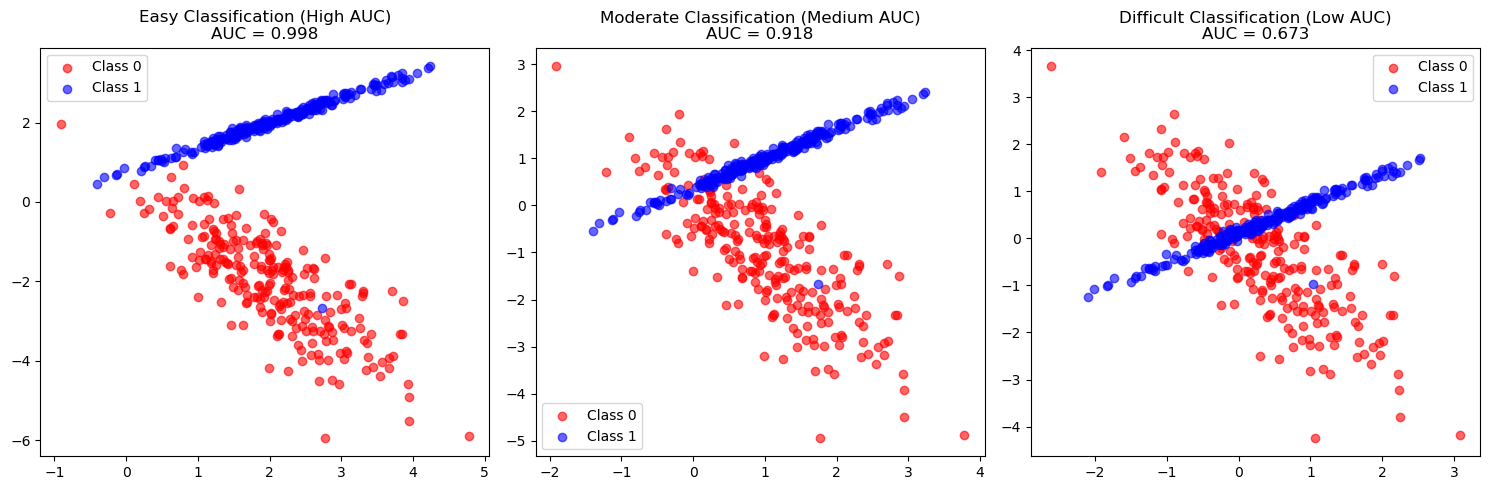

In [12]:
# Create datasets with different separability
plt.figure(figsize=(15, 5))

scenarios = [
    {'class_sep': 2.0, 'title': 'Easy Classification (High AUC)'},
    {'class_sep': 1.0, 'title': 'Moderate Classification (Medium AUC)'},
    {'class_sep': 0.3, 'title': 'Difficult Classification (Low AUC)'}
]

for i, scenario in enumerate(scenarios):
    X, y = make_classification(
        n_samples=500, n_features=2, n_redundant=0, 
        n_informative=2, n_clusters_per_class=1,
        class_sep=scenario['class_sep'], random_state=42
    )
    
    # Train simple logistic regression
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate AUC
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Plot data
    plt.subplot(1, 3, i+1)
    plt.scatter(X[y==0, 0], X[y==0, 1], c='red', alpha=0.6, label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', alpha=0.6, label='Class 1')
    plt.title(f'{scenario["title"]}\nAUC = {auc_score:.3f}')
    plt.legend()

plt.tight_layout()
plt.show()
